In [17]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np

# node2vec
from node2vec import Node2Vec

# clustering
from sklearn.cluster import KMeans, DBSCAN, OPTICS

# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [18]:
from src.community_results import community_metrics, plot_communities
from src.graph_based_clustering import label_propagation, louvain, leiden
from src.DGIModel import DGIModel
from src.tune import tune

In [19]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [20]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [21]:
graphs = dict()

In [22]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [23]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [24]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

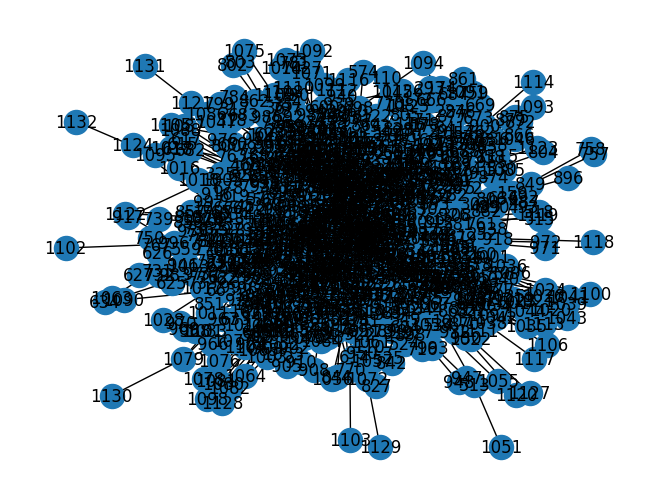

In [25]:
sel_graph = 'univ'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

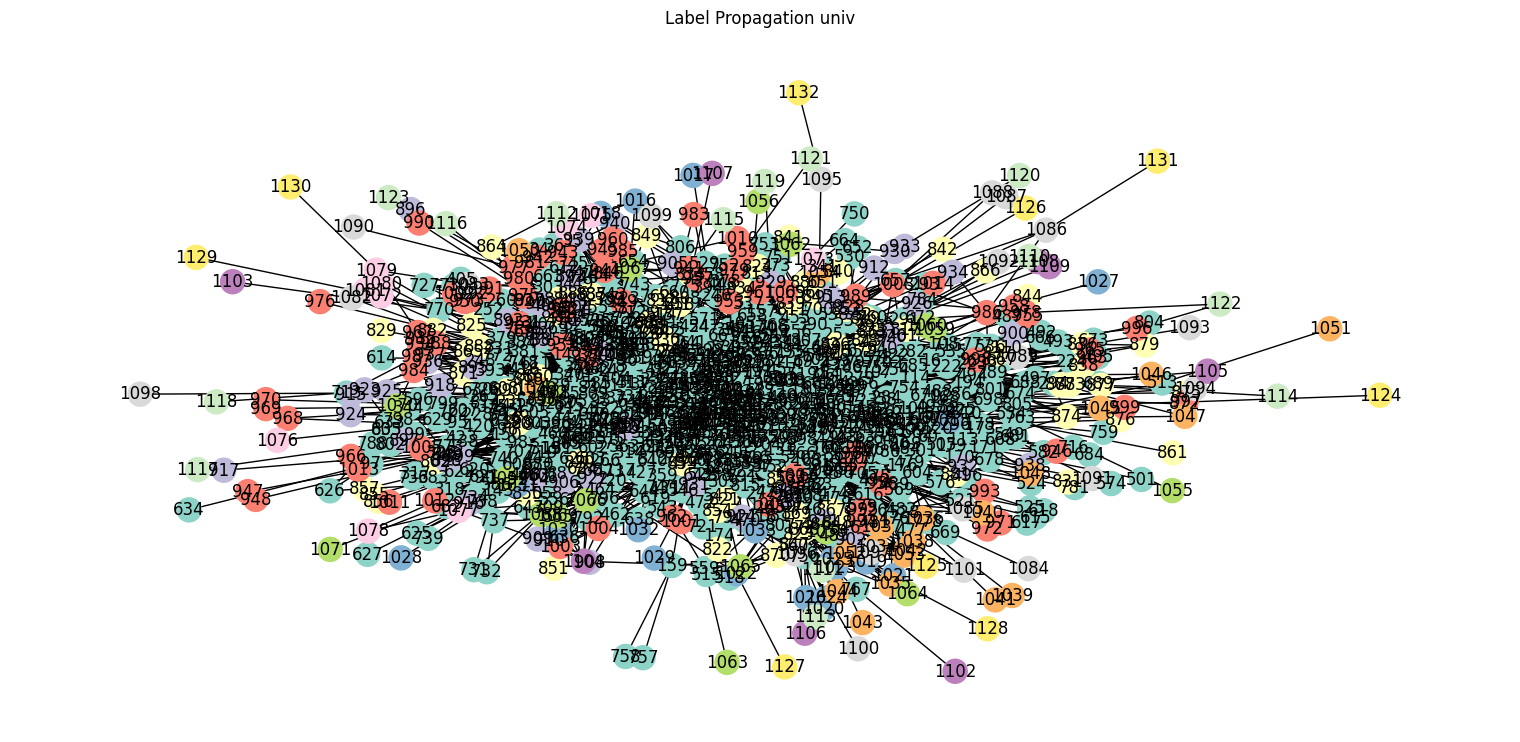

{'Number of Communities': 44,
 'Average Community Size': 25.75,
 'Modularity': 0.4633824482091432,
 'Coverage': 0.744083654375344,
 'Performance': 0.7598685749394178}

In [26]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}")

# Calculate metrics for Louvain
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

## Louvain

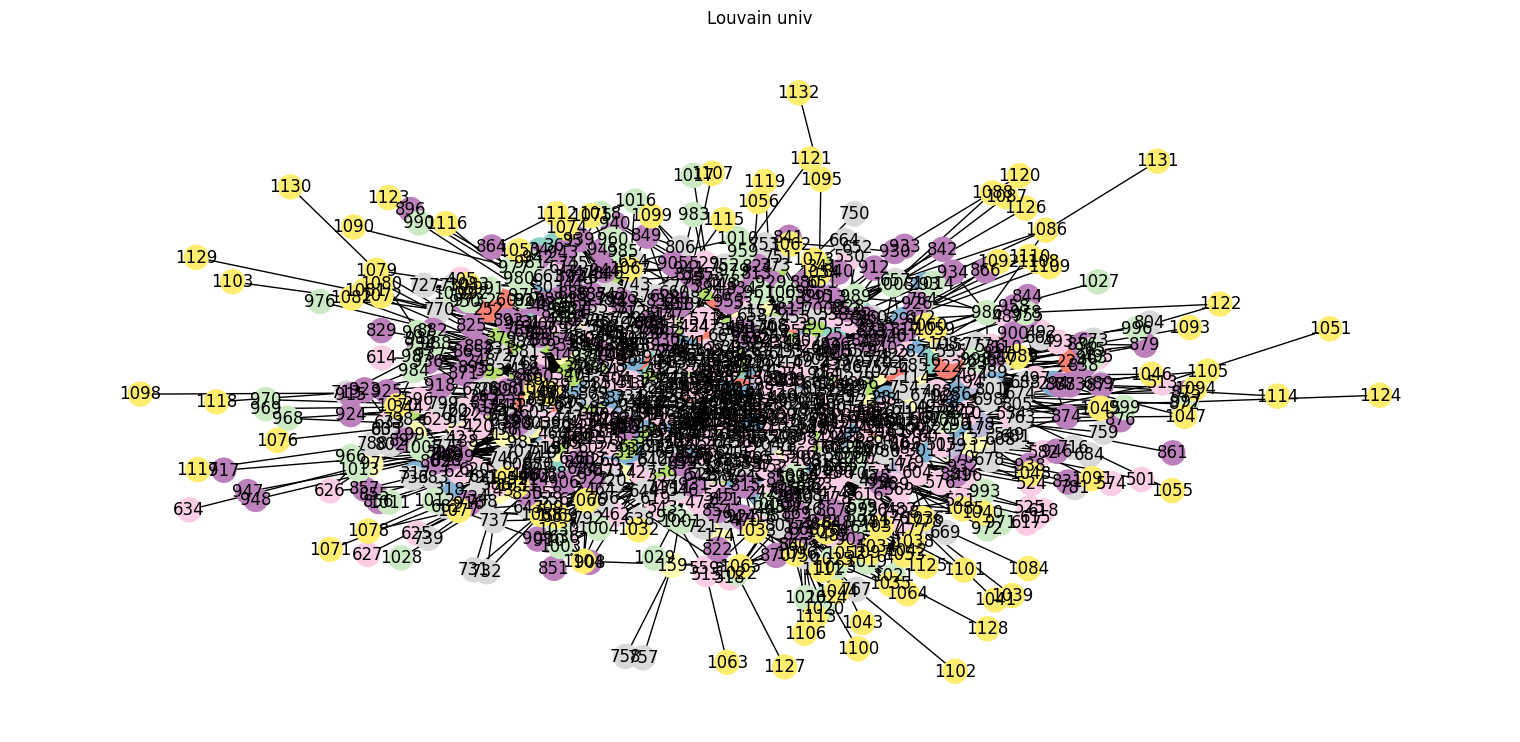

{'Number of Communities': 11,
 'Average Community Size': 103.0,
 'Modularity': 0.5625807190499668,
 'Coverage': 0.6899651440102733,
 'Performance': 0.8833345288626774}

In [27]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}")

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

## Leiden

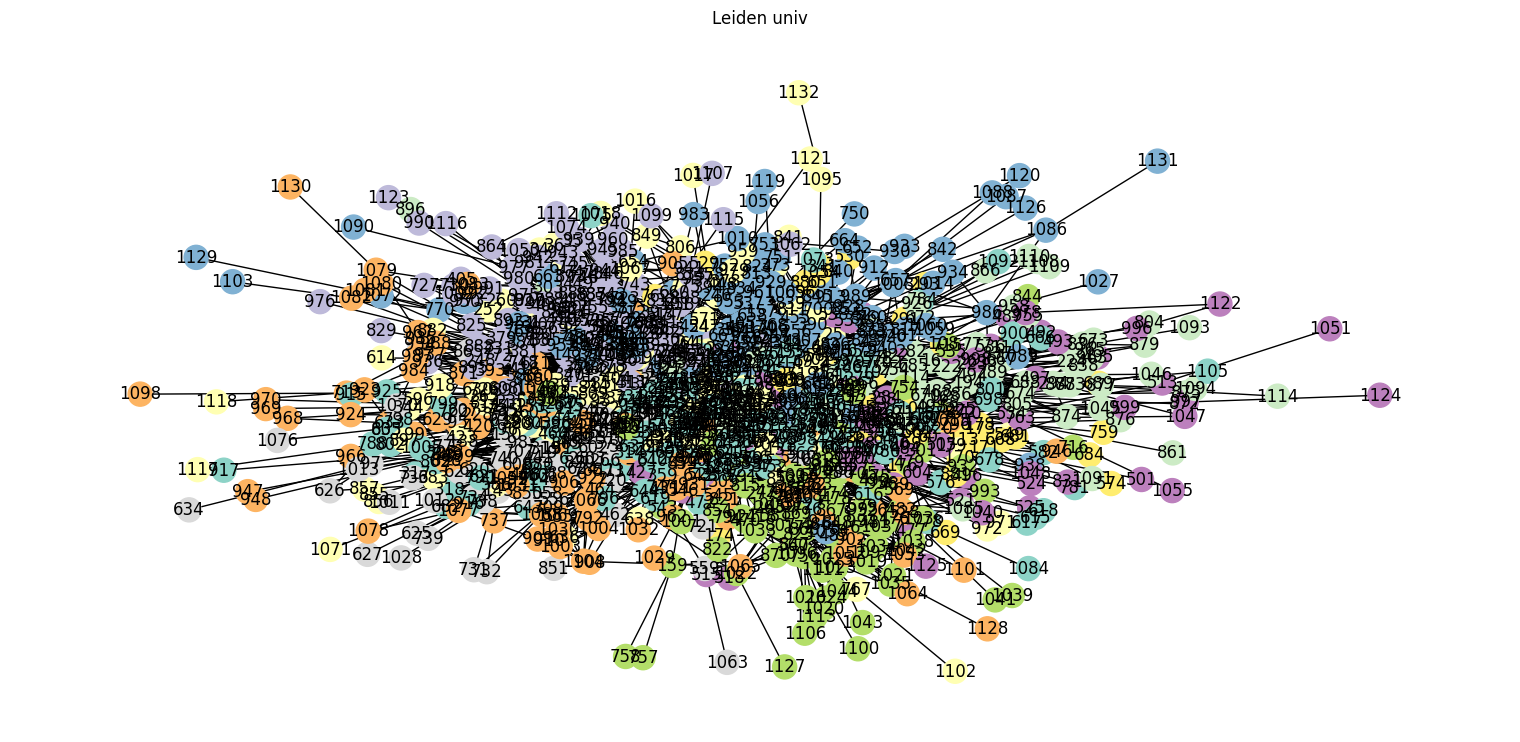

{'Number of Communities': 10,
 'Average Community Size': 113.3,
 'Modularity': 0.5808608714970056,
 'Coverage': 0.7040909924784443,
 'Performance': 0.8938136034605897}

In [28]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}")

# Calculate metrics for Louvain
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

# Apply GAT Embedding

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [30]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [31]:
best_parameters = tune(data)
best_parameters

[I 2024-08-12 01:25:57,874] A new study created in memory with name: no-name-6b2f8f9e-82b0-490f-93db-dede578f81d8


[I 2024-08-12 01:25:59,902] Trial 0 finished with value: -0.00044431130586491935 and parameters: {'hidden_channels': 8, 'out_channels': 9, 'heads': 16, 'learning_rate': 0.005636405903599424, 'dropout': 0.12309388401567056, 'weight_decay': 0.00014697686292215146}. Best is trial 0 with value: -0.00044431130586491935.
[I 2024-08-12 01:26:02,839] Trial 1 finished with value: 0.046327379353174714 and parameters: {'hidden_channels': 59, 'out_channels': 31, 'heads': 13, 'learning_rate': 0.0009406723142658935, 'dropout': 0.15658898789619047, 'weight_decay': 0.0004656269322105108}. Best is trial 1 with value: 0.046327379353174714.
[I 2024-08-12 01:26:04,144] Trial 2 finished with value: 0.11556862844478828 and parameters: {'hidden_channels': 27, 'out_channels': 8, 'heads': 13, 'learning_rate': 0.007655718553570399, 'dropout': 0.5481406526006449, 'weight_decay': 2.7741628971094846e-05}. Best is trial 2 with value: 0.11556862844478828.
[I 2024-08-12 01:26:06,918] Trial 3 finished with value: 0.15

In [33]:
best_parameters.best_value

0.2708388716592893

In [17]:
hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
num_layers = 2
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 400

In [18]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(800):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')


Epoch 0, Loss: 1.3885518312454224
Epoch 10, Loss: 0.2960807681083679
Epoch 20, Loss: 0.01609744131565094
Epoch 30, Loss: 0.008545469492673874
Epoch 40, Loss: 0.0248773954808712
Epoch 50, Loss: 0.004029686562716961
Epoch 60, Loss: 0.004289549775421619
Epoch 70, Loss: 0.0051349494606256485
Epoch 80, Loss: 0.0077591948211193085
Epoch 90, Loss: 0.00423804484307766
Epoch 100, Loss: 0.003116838401183486
Epoch 110, Loss: 0.01780089922249317
Epoch 120, Loss: 0.005792893003672361
Epoch 130, Loss: 0.004514716565608978
Epoch 140, Loss: 0.004933524876832962
Epoch 150, Loss: 0.007193228229880333
Epoch 160, Loss: 0.006977498531341553
Epoch 170, Loss: 0.005895193200558424
Epoch 180, Loss: 0.004952663090080023
Epoch 190, Loss: 0.005990654230117798
Epoch 200, Loss: 0.006803263910114765
Epoch 210, Loss: 0.0023314175195991993
Epoch 220, Loss: 0.00227484293282032
Epoch 230, Loss: 0.005172138102352619
Epoch 240, Loss: 0.006560326553881168
Epoch 250, Loss: 0.005140872672200203
Epoch 260, Loss: 0.00747188739

In [19]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index).detach().cpu().numpy()

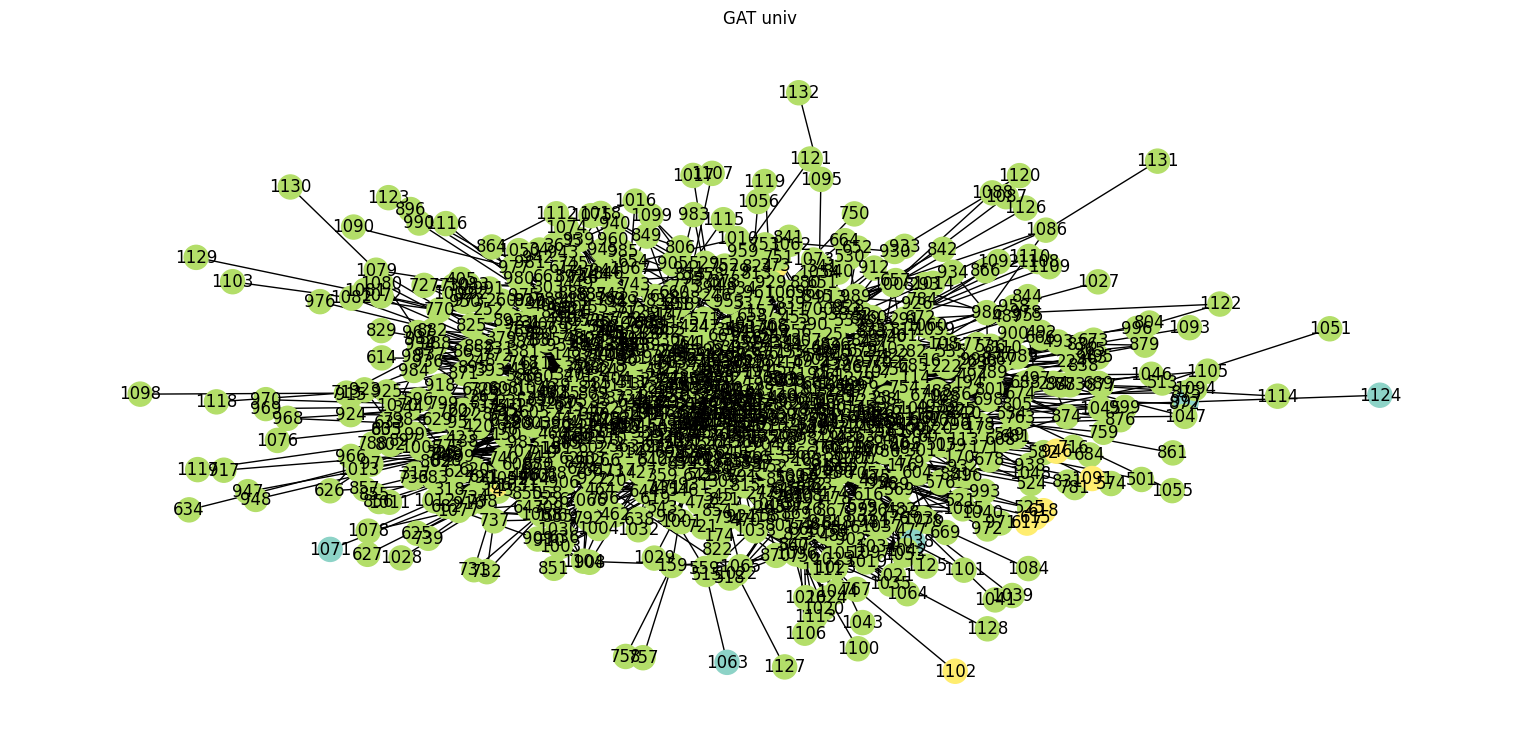

{'Number of Communities': 3,
 'Average Community Size': 377.6666666666667,
 'Modularity': 0.0005442493775788437,
 'Coverage': 0.9965144010273345,
 'Performance': 0.03120799403690755}

In [20]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node_embeddings)
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node_embeddings)
plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

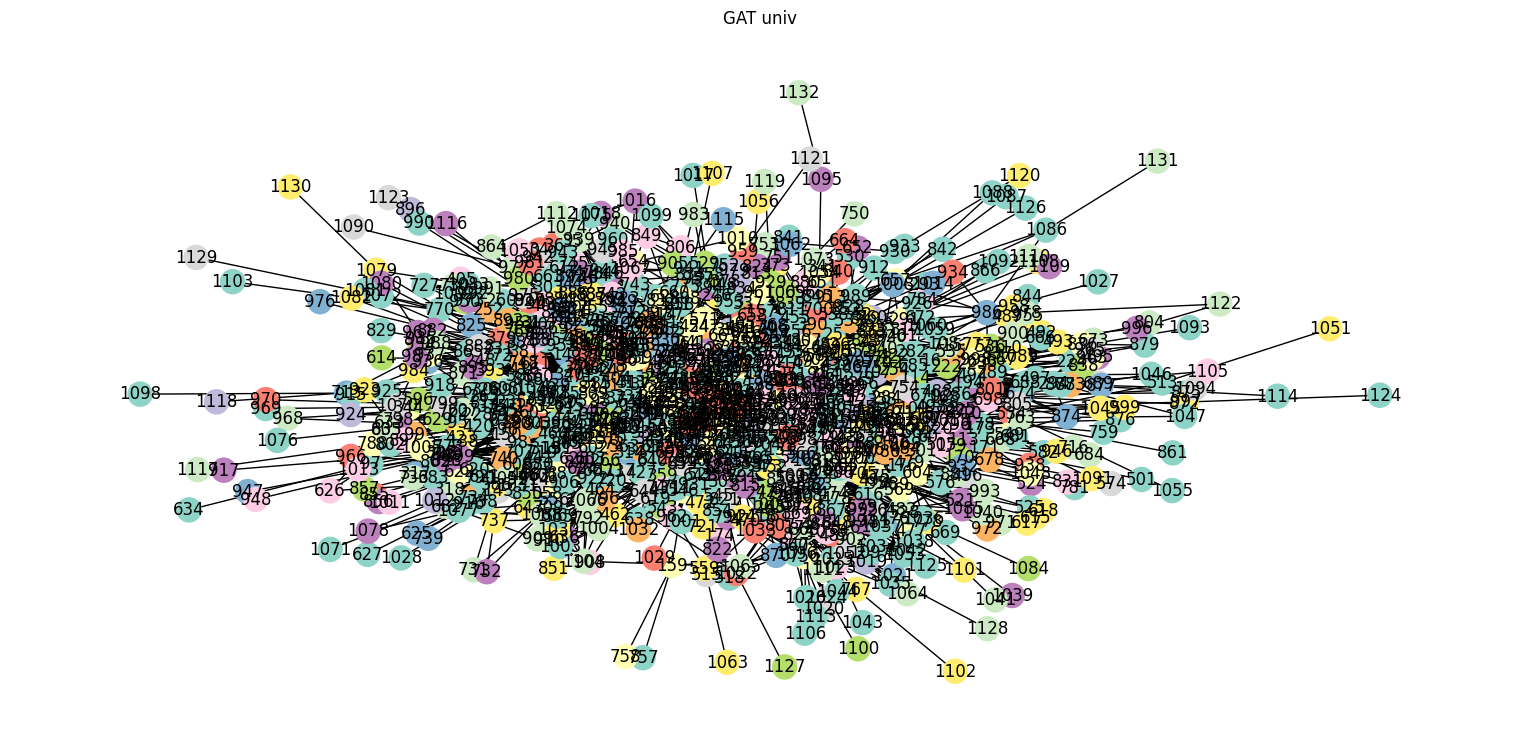

{'Number of Communities': 104,
 'Average Community Size': 10.89423076923077,
 'Modularity': 0.00011171726858194594,
 'Coverage': 0.08273711245643,
 'Performance': 0.9053343479738897}

In [24]:
optics = OPTICS(min_samples=5)
communities = optics.fit_predict(node_embeddings)

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

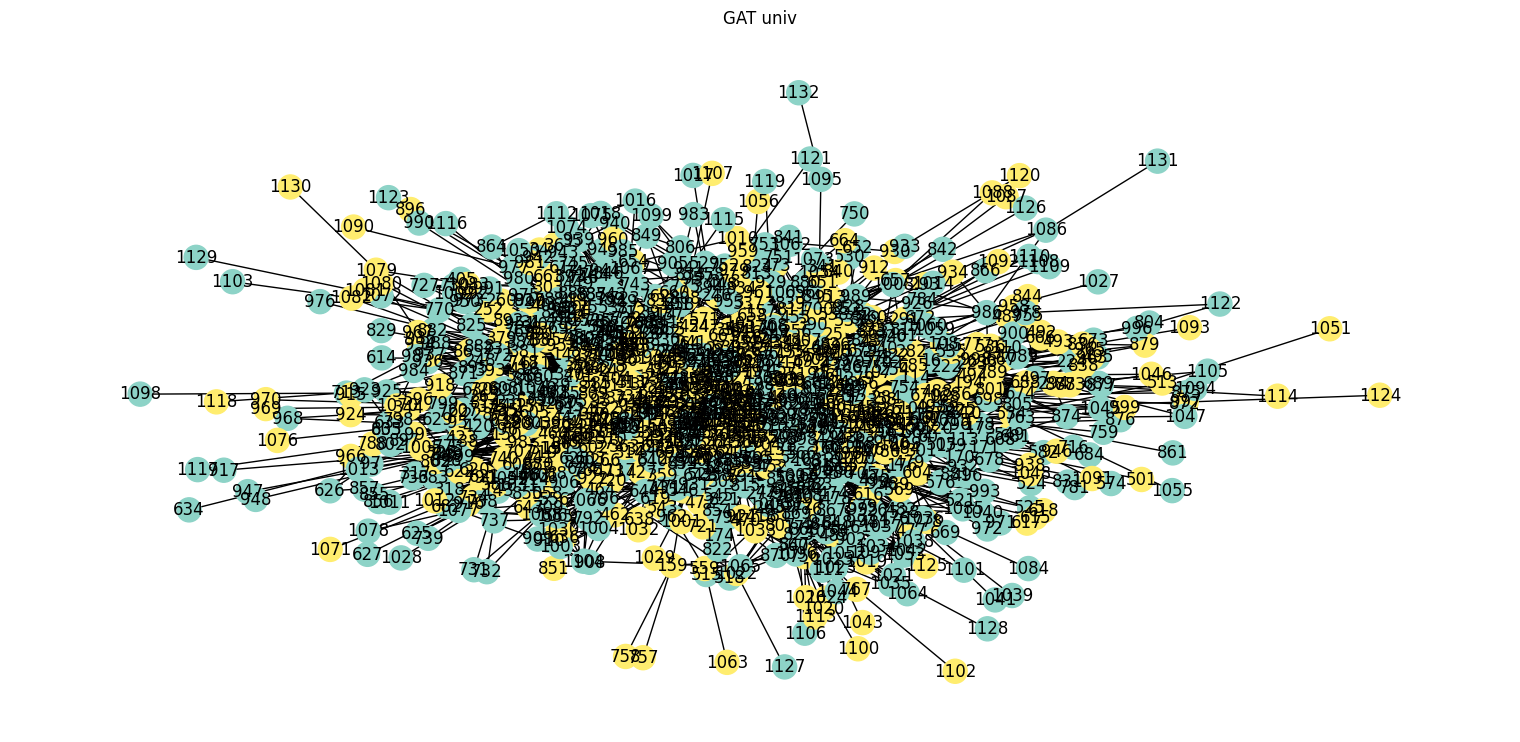

{'Number of Communities': 2,
 'Average Community Size': 566.5,
 'Modularity': 0.2151135778768644,
 'Coverage': 0.7468354430379747,
 'Performance': 0.5031873851901983}

In [21]:
best_n = 0
best_mod = -1

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i)
    communities = kmeans.fit_predict(node_embeddings)
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_n, best_mod = i, mod

kmeans = KMeans(n_clusters=best_n)
communities = kmeans.fit_predict(node_embeddings)

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

In [22]:
# Plotting the communities
# plt.figure(figsize=(8, 6))
# nx.draw(G, node_color=communities, with_labels=True, cmap=plt.cm.rainbow, node_size=500)
# plt.title("Detected Communities in Karate Club Graph")
# plt.show()